In [3]:
import os

print(os.getcwd())

c:\Users\shrit\OneDrive\Desktop\Project_FORESIGHT\notebooks


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the merged dataset
df = pd.read_csv("../data/processed/master_dataset.csv")

print(df.shape)
df.head()

(146200, 26)


,Date,SKU_ID,Units_Sold,Unit_Price,Revenue,Promotion,Category,Subcategory,Launch_Date,Unit_Cost,...,Day,Day_Name,Weekend,Holiday,Season,Current_Stock,On_Order,Lead_Time_Days,Safety_Stock,Reorder_Point
0,2024-01-01,SKU001,38,7766.15,295113.70,0,Furniture,Chair,2023-09-28,3474,...,1,Monday,False,False,Winter,801,348,9,183,366
1,2024-01-02,SKU001,40,7766.15,310646.00,0,Furniture,Chair,2023-09-28,3474,...,2,Tuesday,False,False,Winter,801,348,9,183,366
2,2024-01-03,SKU001,30,7766.15,232984.50,0,Furniture,Chair,2023-09-28,3474,...,3,Wednesday,False,False,Winter,801,348,9,183,366
3,2024-01-04,SKU001,35,7766.15,271815.25,0,Furniture,Chair,2023-09-28,3474,...,4,Thursday,False,False,Winter,801,348,9,183,366
4,2024-01-05,SKU001,37,7766.15,287347.55,0,Furniture,Chair,2023-09-28,3474,...,5,Friday,False,False,Winter,801,348,9,183,366


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 146200 entries, 0 to 146199
Data columns (total 26 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Date            146200 non-null  str    
 1   SKU_ID          146200 non-null  str    
 2   Units_Sold      146200 non-null  int64  
 3   Unit_Price      146200 non-null  float64
 4   Revenue         146200 non-null  float64
 5   Promotion       146200 non-null  int64  
 6   Category        146200 non-null  str    
 7   Subcategory     146200 non-null  str    
 8   Launch_Date     146200 non-null  str    
 9   Unit_Cost       146200 non-null  int64  
 10  List_Price      146200 non-null  float64
 11  Year            146200 non-null  int64  
 12  Month           146200 non-null  int64  
 13  Month_Name      146200 non-null  str    
 14  Week            146200 non-null  int64  
 15  Quarter         146200 non-null  int64  
 16  Day             146200 non-null  int64  
 17  Day_Name        14620

In [7]:
df["Date"] = pd.to_datetime(df["Date"])
df["Launch_Date"] = pd.to_datetime(df["Launch_Date"])

print(df.dtypes)

Date              datetime64[us]
SKU_ID                       str
Units_Sold                 int64
Unit_Price               float64
Revenue                  float64
Promotion                  int64
Category                     str
Subcategory                  str
Launch_Date       datetime64[us]
Unit_Cost                  int64
List_Price               float64
Year                       int64
Month                      int64
Month_Name                   str
Week                       int64
Quarter                    int64
Day                        int64
Day_Name                     str
Weekend                     bool
Holiday                     bool
Season                       str
Current_Stock              int64
On_Order                   int64
Lead_Time_Days             int64
Safety_Stock               int64
Reorder_Point              int64
dtype: object


Dataset Overview

In [8]:
print("=" * 50)
print("PROJECT FORESIGHT - DATASET OVERVIEW")
print("=" * 50)

print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\nColumns")
print(df.columns.tolist())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows :", df.duplicated().sum())

PROJECT FORESIGHT - DATASET OVERVIEW
Rows : 146200
Columns : 26

Columns
['Date', 'SKU_ID', 'Units_Sold', 'Unit_Price', 'Revenue', 'Promotion', 'Category', 'Subcategory', 'Launch_Date', 'Unit_Cost', 'List_Price', 'Year', 'Month', 'Month_Name', 'Week', 'Quarter', 'Day', 'Day_Name', 'Weekend', 'Holiday', 'Season', 'Current_Stock', 'On_Order', 'Lead_Time_Days', 'Safety_Stock', 'Reorder_Point']

Missing Values
Date              0
SKU_ID            0
Units_Sold        0
Unit_Price        0
Revenue           0
Promotion         0
Category          0
Subcategory       0
Launch_Date       0
Unit_Cost         0
List_Price        0
Year              0
Month             0
Month_Name        0
Week              0
Quarter           0
Day               0
Day_Name          0
Weekend           0
Holiday           0
Season            0
Current_Stock     0
On_Order          0
Lead_Time_Days    0
Safety_Stock      0
Reorder_Point     0
dtype: int64

Duplicate Rows : 0


Summary Statistics

In [9]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,146200,2024-12-31 00:00:00,2024-01-01 00:00:00,2024-07-01 00:00:00,2024-12-31 00:00:00,2025-07-02 00:00:00,2025-12-31 00:00:00,NaN
Units_Sold,146200.0,26.404767,0.0,16.0,25.0,36.0,95.0,13.770322
Unit_Price,146200.0,3895.57425,542.94,2127.7825,3534.23,5556.715,9367.85,2163.996782
Revenue,146200.0,103179.229011,0.0,36997.62,81334.46,147093.82,702588.75,83546.897011
Promotion,146200.0,0.100178,0.0,0.0,0.0,0.0,1.0,0.300238
Launch_Date,146200,2024-01-08 09:57:35.999999,2023-01-09 00:00:00,2023-07-14 18:00:00,2024-01-30 12:00:00,2024-07-04 18:00:00,2024-12-29 00:00:00,NaN
Unit_Cost,146200.0,2108.595,301.0,1272.75,1986.0,3004.25,3935.0,1056.663886
List_Price,146200.0,3895.57425,542.94,2127.7825,3534.23,5556.715,9367.85,2163.996782
Year,146200.0,2024.499316,2024.0,2024.0,2024.0,2025.0,2025.0,0.500001
Month,146200.0,6.519836,1.0,4.0,7.0,10.0,12.0,3.449563


Daily Sales Trend

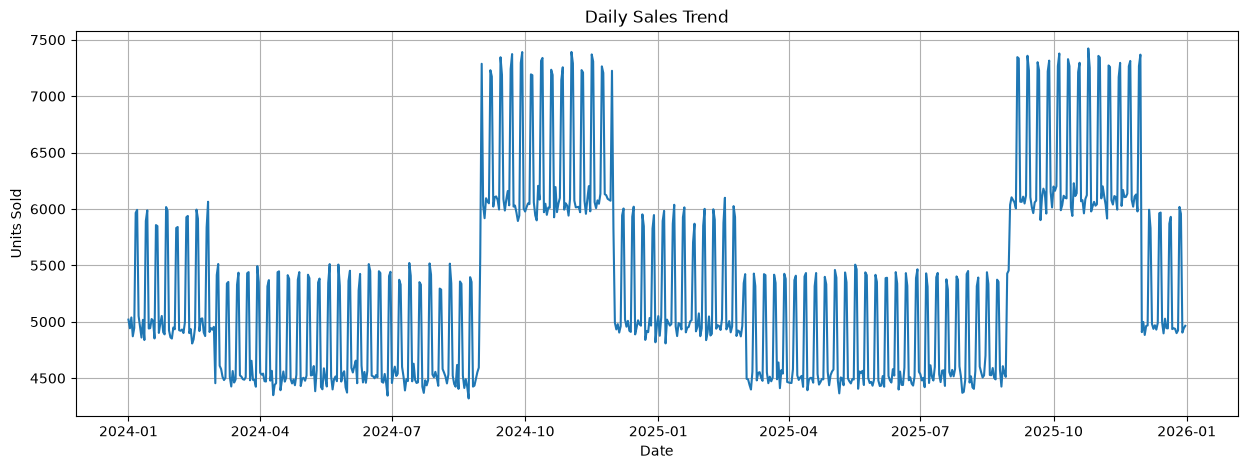

In [10]:
daily_sales = df.groupby("Date")["Units_Sold"].sum()

plt.figure(figsize=(15,5))

plt.plot(daily_sales)

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.grid(True)

plt.show()

Monthly Revenue

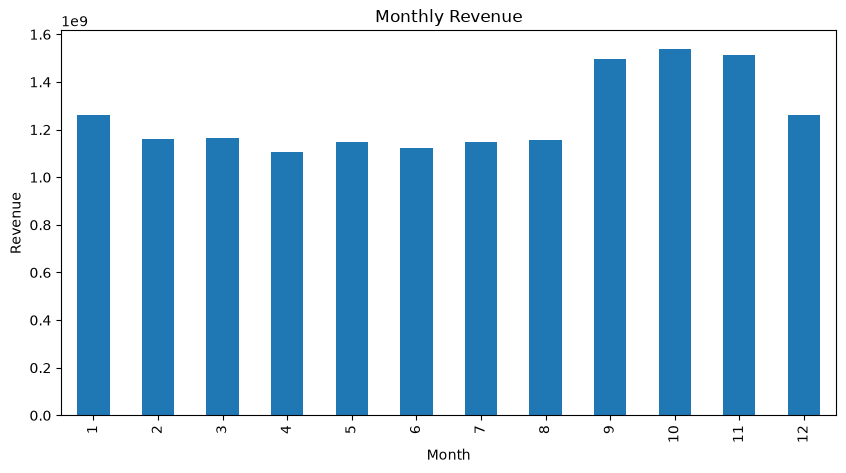

In [11]:
monthly_revenue = df.groupby("Month")["Revenue"].sum()

plt.figure(figsize=(10,5))

monthly_revenue.plot(kind="bar")

plt.title("Monthly Revenue")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.show()

Revenue by Category

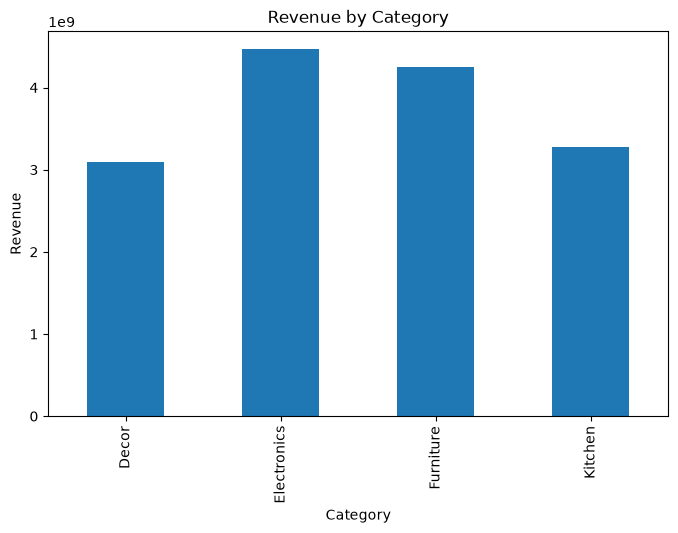

In [12]:
category = df.groupby("Category")["Revenue"].sum()

plt.figure(figsize=(8,5))

category.plot(kind="bar")

plt.title("Revenue by Category")

plt.ylabel("Revenue")

plt.show()

Promotion Effect

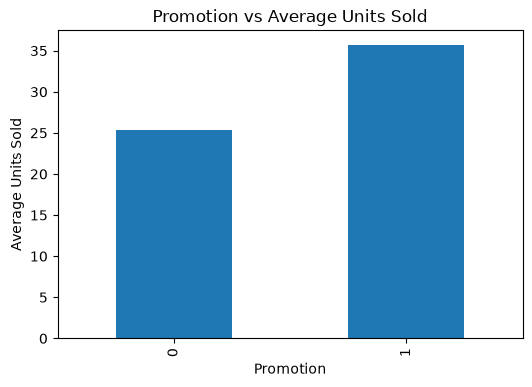

In [13]:
promotion = df.groupby("Promotion")["Units_Sold"].mean()

plt.figure(figsize=(6,4))

promotion.plot(kind="bar")

plt.title("Promotion vs Average Units Sold")

plt.ylabel("Average Units Sold")

plt.show()

Top 10 Products

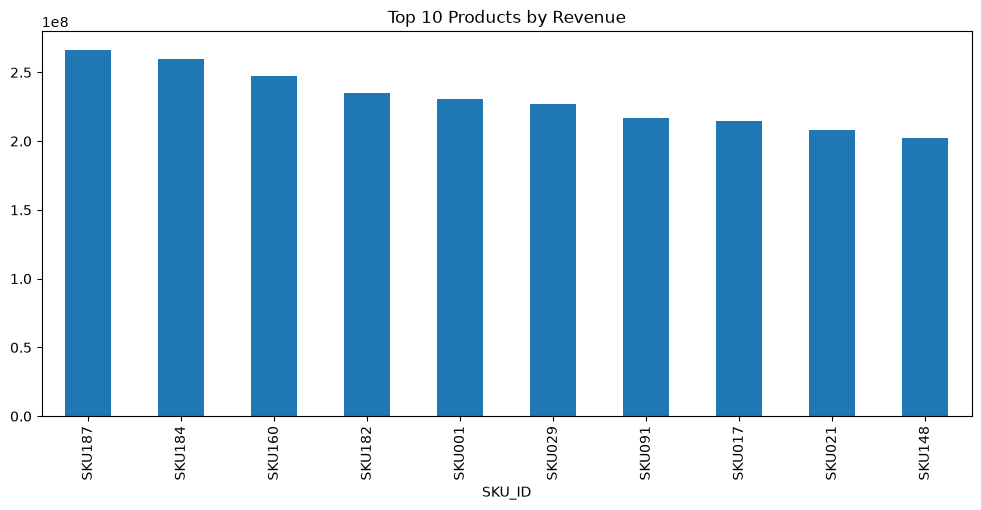

In [14]:
top = (
    df.groupby("SKU_ID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,5))

top.plot(kind="bar")

plt.title("Top 10 Products by Revenue")

plt.show()

Inventory Distribution

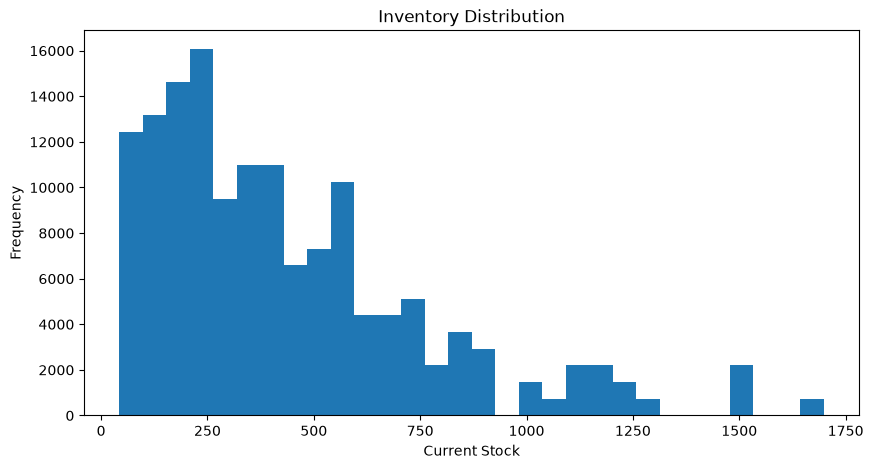

In [15]:
plt.figure(figsize=(10,5))

plt.hist(df["Current_Stock"], bins=30)

plt.title("Inventory Distribution")

plt.xlabel("Current Stock")

plt.ylabel("Frequency")

plt.show()

Revenue Distribution

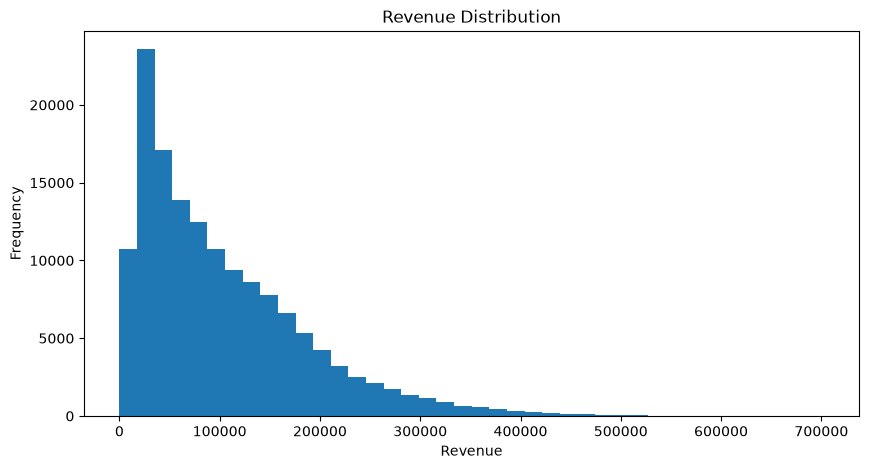

In [16]:
plt.figure(figsize=(10,5))

plt.hist(df["Revenue"], bins=40)

plt.title("Revenue Distribution")

plt.xlabel("Revenue")

plt.ylabel("Frequency")

plt.show()

Correlation Matrix

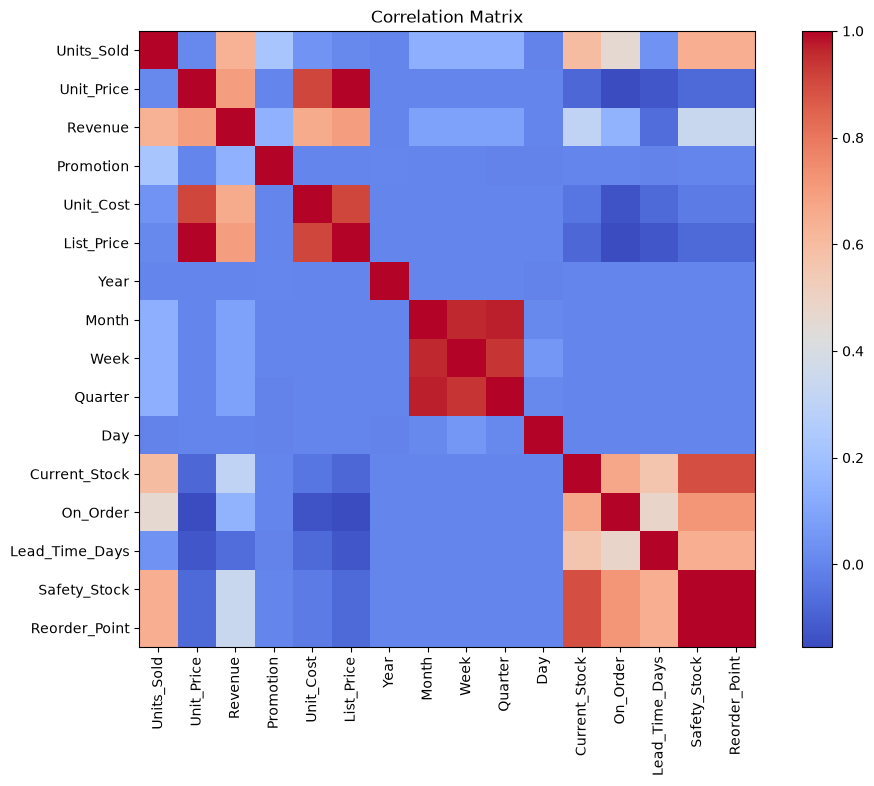

In [17]:
import numpy as np

numeric = df.select_dtypes(include=np.number)

corr = numeric.corr()

plt.figure(figsize=(12,8))

plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()